In [2]:
# Input data as a multiline string
data = """
LAE-1 23:50:39.46 31:47:26.41 24.97 0.16 24.11 0.12
LAE-2 23:49:25.39 31:46:34.95 26.07 0.43 24.73 0.22
LAE-3 23:49:45.53 31:39:01.46 25.74 0.33 24.59 0.19
LAE-4 23:48:22.23 31:37:53.92 25.93 0.38 24.46 0.17
LAE-5 23:48:17.08 31:30:18.94 26.09 0.45 23.59 0.07
LAE-6 23:46:51.65 31:19:29.93 25.85 0.36 24.37 0.16
LAE-7 23:52:04.95 31:16:20.60 25.38 0.24 23.50 0.07
LAE-8 23:44:51.34 31:14:01.78 25.99 0.42 24.08 0.12
LAE-9 23:49:09.11 31:11:23.68 25.84 0.36 24.53 0.18
LAE-10 23:48:38.18 31:10:25.4 26.12 0.47 24.49 0.18
LAE-11 23:52:11.44 31:10:09.8 25.55 0.28 24.47 0.18
LAE-12 23:50:09.67 31:00:28.4 25.54 0.28 24.20 0.14
LAE-13 23:52:50.08 30:59:23.0 25.81 0.36 24.37 0.16
LAE-14 23:46:52.33 30:57:07.0 26.07 0.44 24.66 0.22
LAE-15 23:52:39.27 30:51:50.7 25.44 0.27 24.32 0.16
LAE-16 23:51:42.32 30:50:46.9 25.33 0.23 24.46 0.16
LAE-17 23:45:30.76 30:50:42.2 25.86 0.37 24.72 0.22
LAE-18 23:45:38.56 30:41:06.2 25.69 0.32 24.28 0.14
LAE-19 23:50:56.96 30:40:16.9 26.03 0.43 24.07 0.12
LAE-20 23:46:20.25 30:40:03.9 25.38 0.24 24.57 0.19
LAE-21 23:48:12.27 30:32:34.3 26.02 0.42 24.22 0.14
LAE-22 23:44:45.07 30:31:07.1 26.05 0.45 24.52 0.18
LAE-23 23:47:37.50 30:28:28.3 25.53 0.27 24.60 0.20
LAE-24 23:44:31.64 30:27:35.7 25.39 0.24 24.41 0.17
LAE-25 23:47:38.55 30:25:47.7 25.33 0.23 24.49 0.18
LAE-26 23:44:36.91 30:25:04.4 25.95 0.40 23.97 0.11
LAE-27 23:48:21.02 30:24:04.1 26.00 0.41 24.52 0.18
LAE-28 23:47:21.19 30:22:53.5 25.63 0.30 23.84 0.10
LAE-29 23:46:27.28 30:21:51.5 25.52 0.27 24.40 0.16
LAE-30 23:49:27.05 30:21:25.9 25.65 0.30 24.61 0.19
LAE-31 23:50:27.20 30:21:13.3 25.50 0.27 24.26 0.14
LAE-32 23:45:02.91 30:12:32.8 25.96 0.39 24.73 0.21
LAE-33 23:49:34.65 30:12:40.4 25.66 0.31 24.52 0.18
LAE-34 23:50:23.24 30:10:45.4 26.13 0.48 24.62 0.20
LAE-35 23:50:45.07 30:05:13.3 25.34 0.23 24.32 0.15
LAE-36 23:49:43.48 30:03:01.2 25.55 0.28 24.31 0.15
LAE-37 23:50:36.54 30:01:46.7 25.45 0.25 24.58 0.19
LAE-38 23:48:43.58 29:53:13.9 25.80 0.36 24.70 0.22
"""

# Open a file to write RA and Dec
with open("/Users/aishwarya/Desktop/lae_ra_dec.txt", "w") as f:
    # Process each line
    for line in data.strip().split("\n"):
        parts = line.split()
        ra = parts[1]
        dec = parts[2]
        f.write(f"{ra} {dec}\n")

print("RA and Dec saved to lae_ra_dec.txt")

RA and Dec saved to lae_ra_dec.txt



--- DEBUG INFO ---


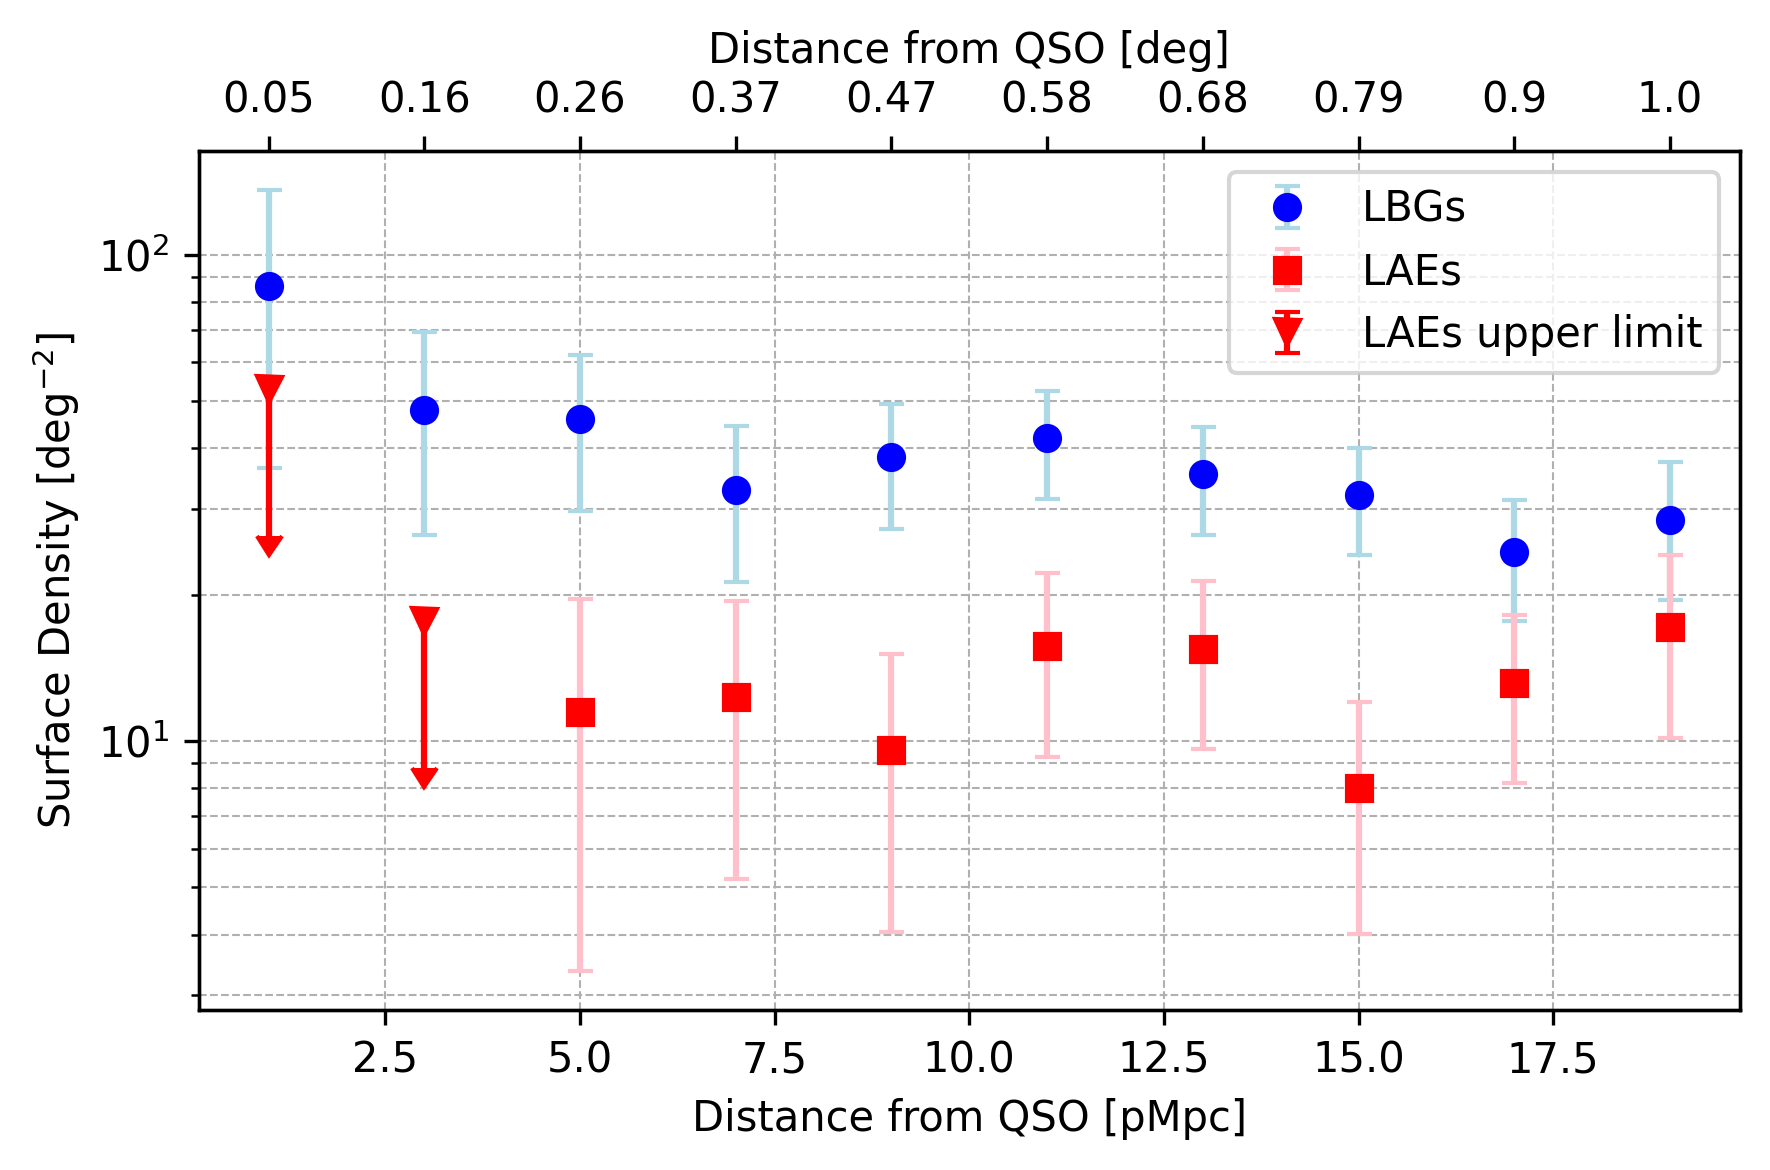

Saved plot: plots/lbg_lae_debug_surface_density.png


In [14]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import os

# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
ARCSEC_PER_KPC_CO = COSMO.arcsec_per_kpc_comoving(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)

# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)
        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)
        good_pixels = (self.data > 0.5) & annulus
        return np.sum(good_pixels) * self.pix_area_deg

    @property
    def center(self):
        rows, cols = self.data.shape
        return self.wcs.pixel_to_world_values(cols/2, rows/2)

# ----------------------------
# Distance calculation
# ----------------------------
def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    # Source to remove
    remove_ra = 358.19302900
    remove_dec = -30.94298720

    # Remove the source if it exists
    mask = ~((np.isclose(ras, remove_ra, atol=1e-6)) &
             (np.isclose(decs, remove_dec, atol=1e-6)))

    ras = ras[mask]
    decs = decs[mask]

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras.astype(float)*u.deg, decs.astype(float)*u.deg)

    return center_coord.separation(sources)

# ----------------------------
# Surface density computation
# ----------------------------
def compute_surface_density(counts, areas):
    areas = np.array([a.value for a in areas])
    y = counts / areas
    yerr = np.sqrt(counts) / areas
    return y, yerr

# ----------------------------
# Poisson upper limits for non-detections
# ----------------------------
def poisson_upper_limit(counts, areas):
    areas = np.array([a.value for a in areas])
    y_upper = np.zeros_like(counts, dtype=float)
    for i, c in enumerate(counts):
        if c == 0:
            # Gehrels 1986 1-sigma upper limit for zero counts
            y_upper[i] = 1.841 / areas[i]
        else:
            # Approximate 1-sigma upper limit for non-zero counts
            y_upper[i] = (c + np.sqrt(c + 0.75)) / areas[i]
    return y_upper

# ----------------------------
# Debugging and plotting
# ----------------------------
def debug_and_plot(radii_mpc, radii_deg, counts_lbg, areas_lbg, counts_lae, areas_lae, outfile):
    print("\n--- DEBUG INFO ---")
    
    y_lbg, yerr_lbg = compute_surface_density(counts_lbg, areas_lbg)
    y_lae, yerr_lae = compute_surface_density(counts_lae, areas_lae)
    y_lae_upper = poisson_upper_limit(counts_lae, areas_lae)

    fig, ax = plt.subplots(figsize=(6,4), dpi=300)
    # LBGs
    ax.errorbar(radii_mpc, y_lbg, yerr=yerr_lbg, fmt='o', color='blue', ecolor='lightblue', capsize=3, label='LBGs')
    # LAEs detections
    detected = counts_lae > 0
    ax.errorbar(radii_mpc[detected], y_lae[detected], yerr=yerr_lae[detected],
                fmt='s', color='red', ecolor='pink', capsize=3, label='LAEs')
    # LAEs non-detections
    nondetected = counts_lae == 0
    ax.errorbar(radii_mpc[nondetected], y_lae_upper[nondetected],
                yerr=0.5*y_lae_upper[nondetected], fmt='v', color='red',
                uplims=True, label='LAEs upper limit')

    ax.set_yscale('log')
    ax.set_xlabel("Distance from QSO [pMpc]")
    ax.set_ylabel("Surface Density [deg$^{-2}$]")
    ax.legend()
    ax.grid(True, which='both', ls='--', lw=0.5)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from QSO [deg]")

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()
    print(f"Saved plot: {outfile}")

# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":
    # Catalogs
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"
    LAE_CATALOG   = "/Users/aishwarya/Desktop/lae_ra_dec_deg.txt"

    # Mask
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"
    decam = Mask(DECAM_MASK_FILE)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    # Radial bins
    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC
    radii_pix_decam = radii_deg / decam.deg_per_pix
    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    # Compute areas
    areas_decam = [decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
                   for i in range(len(radii_pix_decam)-1)]

    # Compute distances
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)
    dist_lae   = calculate_distances((RA_QSO, DEC_QSO), LAE_CATALOG)

    # Keep sources at zero distance (include QSO if present)
    dist_decam = dist_decam[dist_decam >= 0*u.deg]
    dist_lae   = dist_lae[dist_lae >= 0*u.deg]

    # Compute counts per bin
    # Compute counts per bin (fixed: remove .value)
    counts_decam = np.array([np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
                         for i in range(len(radii_deg)-1)])
    counts_lae   = np.array([np.sum((dist_lae >= radii_deg[i]) & (dist_lae < radii_deg[i+1]))
                         for i in range(len(radii_deg)-1)])
    # Debug & plot
    os.makedirs("plots", exist_ok=True)
    debug_and_plot(
        radii_mid_mpc.value,
        radii_mid_deg,
        counts_decam, areas_decam,
        counts_lae, areas_decam,  # assuming same mask as DECAM
        "plots/lbg_lae_debug_surface_density.png"
    )

In [8]:
a = "/Users/aishwarya/Desktop/lae_ra_dec_deg.txt"

In [9]:
with open(a, 'r') as f:
    num_rows = sum(1 for _ in f)
print(num_rows)

39


Number of columns: 2


In [5]:
len(a)

53

In [18]:
file1 = "/Users/aishwarya/Desktop/lae_ra_dec_deg.txt"
file2 = "/Users/aishwarya/Desktop/comparision/Not_Source_updated.txt"
ra = np.loadtxt(file1, usecols=0)
dec = np.loadtxt(file1, usecols=1)
ra2 = np.loadtxt(file2, usecols=0)
dec2 = np.loadtxt(file2, usecols=1)
cat1 = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
cat2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg)

# Match catalog 1 to catalog 2
idx, d2d, _ = cat1.match_to_catalog_sky(cat2)

# Define matching tolerance (e.g. 1 arcsec)
tolerance = 1.0 * u.arcsec

# Find matches
matches = d2d < tolerance

# Results
matched_cat1 = cat1[matches]
matched_cat2 = cat2[idx[matches]]

print(f"Number of overlapping sources: {len(matched_cat1)}")





Number of overlapping sources: 0
